In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import clip
import random
import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [4]:
train_ds = datasets.STL10(
    root="stl10/",
    split="train",
    download=True,
    transform=preprocess)

test_ds = datasets.STL10(
    root="stl10/",
    split="test",
    download=True,
    transform=preprocess,
    )


In [5]:
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

# 3) STL-10 class names (official order)
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# 4) Prompt strategies
prompt_sets = {
    "plain": [c for c in class_names],
    "photo": [f"a photo of a {c}" for c in class_names],
    "descriptive": [
        f"a photo of a {c}, a type of object from the STL-10 dataset"
        for c in class_names
    ],
}

# 5) Precompute text features for each prompt set
text_features = {}
with torch.no_grad():
    for name, prompts in prompt_sets.items():
        tokens = clip.tokenize(prompts).to(device)
        feats = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        text_features[name] = feats

# 6) Evaluate
def accuracy_for_prompt(text_feat):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            img_feat = model.encode_image(images)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

            # cosine similarity
            logits = img_feat @ text_feat.T
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

for name, feats in text_features.items():
    acc = accuracy_for_prompt(feats)
    print(f"{name}: {acc:.4f}")

plain: 0.9624
photo: 0.9738
descriptive: 0.9744


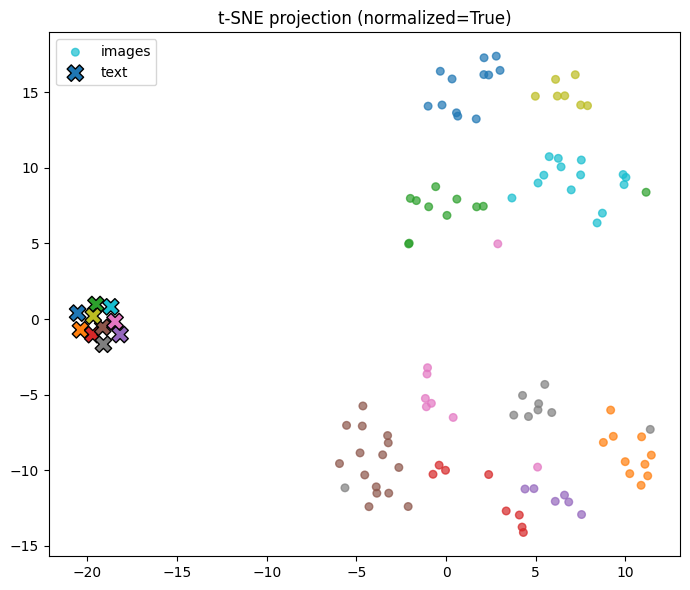

In [9]:
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

# --- load STL-10 test set ---
ds = datasets.STL10(root="stl10", split="test", download=True, transform=preprocess)

# --- sample 100 images ---
N = 100
idxs = random.sample(range(len(ds)), N)
images = []
labels = []
for i in idxs:
    img, lab = ds[i]
    images.append(img)
    labels.append(lab)

images = torch.stack(images).to(device)
labels = torch.tensor(labels).to(device)

# --- make label prompts (one per class) ---
prompts = [f"a photo of a {c}" for c in class_names]
text_tokens = clip.tokenize(prompts).to(device)

with torch.no_grad():
    img_feat = model.encode_image(images)
    txt_feat = model.encode_text(text_tokens)

# --- optional normalization toggle ---
def maybe_norm(x, do_norm=True):
    return x / x.norm(dim=-1, keepdim=True) if do_norm else x

do_norm = True  # set False to compare raw embeddings
img_feat = maybe_norm(img_feat, do_norm)
txt_feat = maybe_norm(txt_feat, do_norm)

# --- stack for projection (images + text) ---
X = torch.cat([img_feat, txt_feat], dim=0).cpu().numpy()

# --- 2D projection ---
# Option A: UMAP (recommended if available)
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    X2 = reducer.fit_transform(X)
    method = "UMAP"
except ImportError:
    # Option B: t-SNE fallback
    from sklearn.manifold import TSNE
    X2 = TSNE(n_components=2, perplexity=15, init="random", random_state=42).fit_transform(X)
    method = "t-SNE"

# --- plot ---
plt.figure(figsize=(7, 6))
# images = first N points
plt.scatter(X2[:N, 0], X2[:N, 1], c=labels.cpu(), cmap="tab10", s=30, alpha=0.7, label="images")
# text = last 10 points (one per class)
plt.scatter(X2[N:, 0], X2[N:, 1], c=range(10), cmap="tab10", s=140, marker="X", edgecolor="k", label="text")

plt.title(f"{method} projection (normalized={do_norm})")
plt.legend(loc="best")
plt.tight_layout()
plt.show()